# Librerías, semilla y carga de datos

In [4]:
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras import regularizers
from tensorflow.keras import callbacks, layers, models
from pathlib import Path
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os, numpy as np, pandas as pd, tensorflow as tf
import scipy.stats as st
import statsmodels.api as sm

# ---------- Reproducibilidad
SEED = 62778
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# Ruta del archivo (ajusta si lo colocas en otra carpeta)
DATA_PATH = Path("Base_Lago_Caburgua.xlsx")
assert DATA_PATH.exists(), f"No se encontró {DATA_PATH}"

df_sin_dique = pd.read_excel(DATA_PATH, sheet_name="LSTM_Sin Reinstalacion Dique")
df_con_dique = pd.read_excel(DATA_PATH, sheet_name="LSTM_Con Reinstalacion Dique")

# Análisis Exploratorio de los datos  

Para esta sección unicamente se utilizará la base sin reinstalación del dique debido a que los datos no afectan nada y son bases exactamente iguales en sus variables continuas, solo difieres en la variable dummy relacionada al dique

 Revisión rápida: tipos, nulos y estadísticos  

In [2]:
df= df_sin_dique

print("Dimensiones:", df.shape)
print("\nTipos de dato:")
display(df.dtypes)

print("\nValores faltantes (conteo):")
display(df.isna().sum())

print("\nResumen estadístico de continuas:")
display(df.describe().T.style.format("{:.2f}"))

Dimensiones: (47, 6)

Tipos de dato:


,0
Año,int64
Superficie_Aproximada,float64
Precipitaciones_Anuales,float64
Temperatura_Minima_Media,float64
Temperatura_Maxima_Media,float64
Presencia_Dique,int64



Valores faltantes (conteo):


,0
Año,0
Superficie_Aproximada,8
Precipitaciones_Anuales,0
Temperatura_Minima_Media,0
Temperatura_Maxima_Media,0
Presencia_Dique,0



Resumen estadístico de continuas:


,count,mean,std,min,25%,50%,75%,max
Año,47.00,2007.00,13.71,1984.00,1995.50,2007.00,2018.50,2030.00
Superficie_Aproximada,39.00,51.55,0.82,50.02,50.87,51.47,52.05,53.27
Precipitaciones_Anuales,47.00,2586.33,711.65,1584.30,2145.85,2385.79,2739.85,5191.50
Temperatura_Minima_Media,47.00,-0.26,0.60,-1.71,-0.68,-0.36,0.06,1.51
Temperatura_Maxima_Media,47.00,24.20,1.06,22.01,23.59,23.95,25.09,26.25
Presencia_Dique,47.00,0.32,0.47,0.00,0.00,0.00,1.00,1.00


Observamos que en la única variable que existen valores faltantes es en superficie aproximada, esto es debido a que todas las otras variables ya presentan su predicción hasta 2030 excepto la variable respuesta de este estudio. (la forma en que se obtuvieron las predicciones se encuentra en el github)

Podemos observar que la media de la superficie del lago caburgua es de 51.55 $km^2$ y tiene fluctuaciones entre los 50.02 y 53.27 $km^2$. Por otro lado, las covariables presentan medias de 2586.33 mm anuales y fluctuaciones entre 1584.3 y 5191.5 mm este ultimo corresponde al registro del año 1993. Para las temperaturas minímas y máximas en promedio se encuentran entre los -0.26 °C y 24.2 °C respectivamente.

Correlaciones:

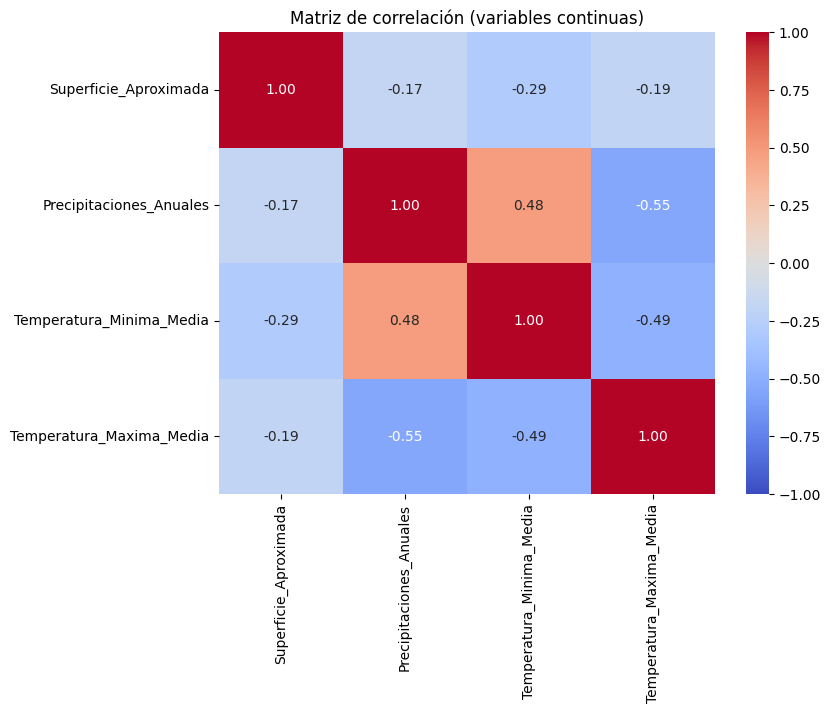

In [5]:
corr = df[["Superficie_Aproximada","Precipitaciones_Anuales","Temperatura_Minima_Media","Temperatura_Maxima_Media"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="coolwarm")
plt.title("Matriz de correlación (variables continuas)")
plt.show()

Notamos que existen correlaciones leves entre la variable respuesta y sus covariables continuas, además de correlaciones moderadas entre las temperaturas y las precipitaciones anuales.

Distribución & outliers (histogramas y boxplots)

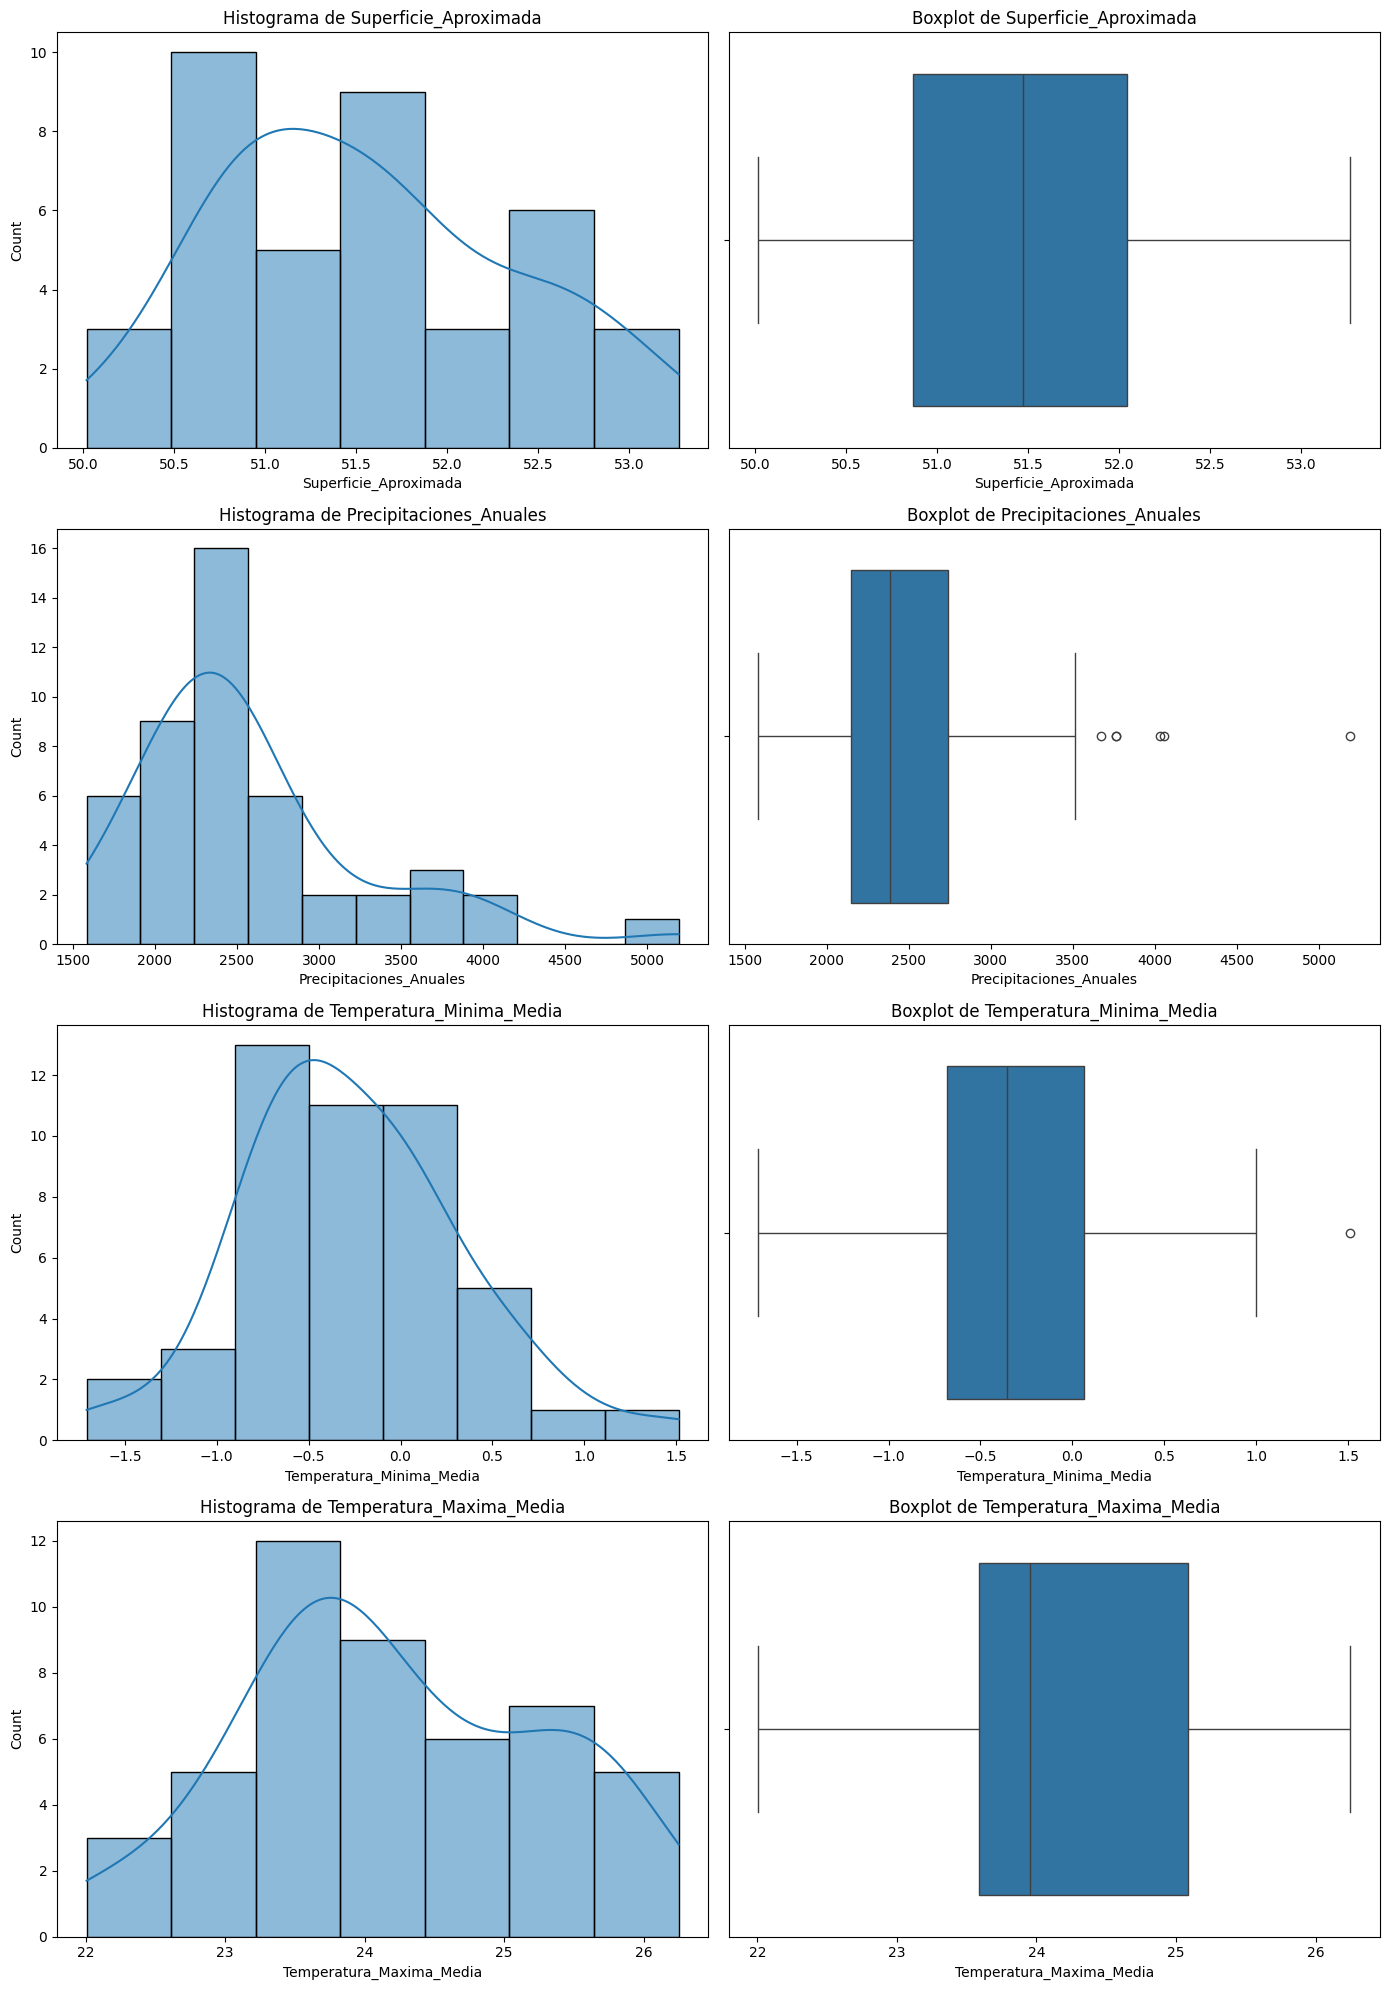

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(14, 20))

for i, var in enumerate(["Superficie_Aproximada","Precipitaciones_Anuales","Temperatura_Minima_Media","Temperatura_Maxima_Media"]):
    # Histograma
    sns.histplot(df[var], ax=axes[i, 0], kde=True)
    axes[i, 0].set_title(f"Histograma de {var}")

    # Boxplot
    sns.boxplot(x=df[var], ax=axes[i, 1], orient="h")
    axes[i, 1].set_title(f"Boxplot de {var}")

plt.tight_layout()
plt.show()

Como se puede visualizar, las precipitaciones anuales presentan valores atípicos por sobre el límite superior según el criterio de Tukey al igual que la temperatura mínima.

la mayor consentración de datos para las precipitaciones es entre 1900 y 2600 mm anuales aproximadamente, mientras que para el promedio de temperatura mínima y máxima, las concentraciones se encuentran entre -0.9 y 0.4 aproximadamente y 23.2 y 25 aproximadamente, respectivamente. Por otro lado para la variable respuesta de esta investigación no se presentan datos atípicos y presenta diversos intervalos con una alta concentración de datos.

 Scatter–matrix:

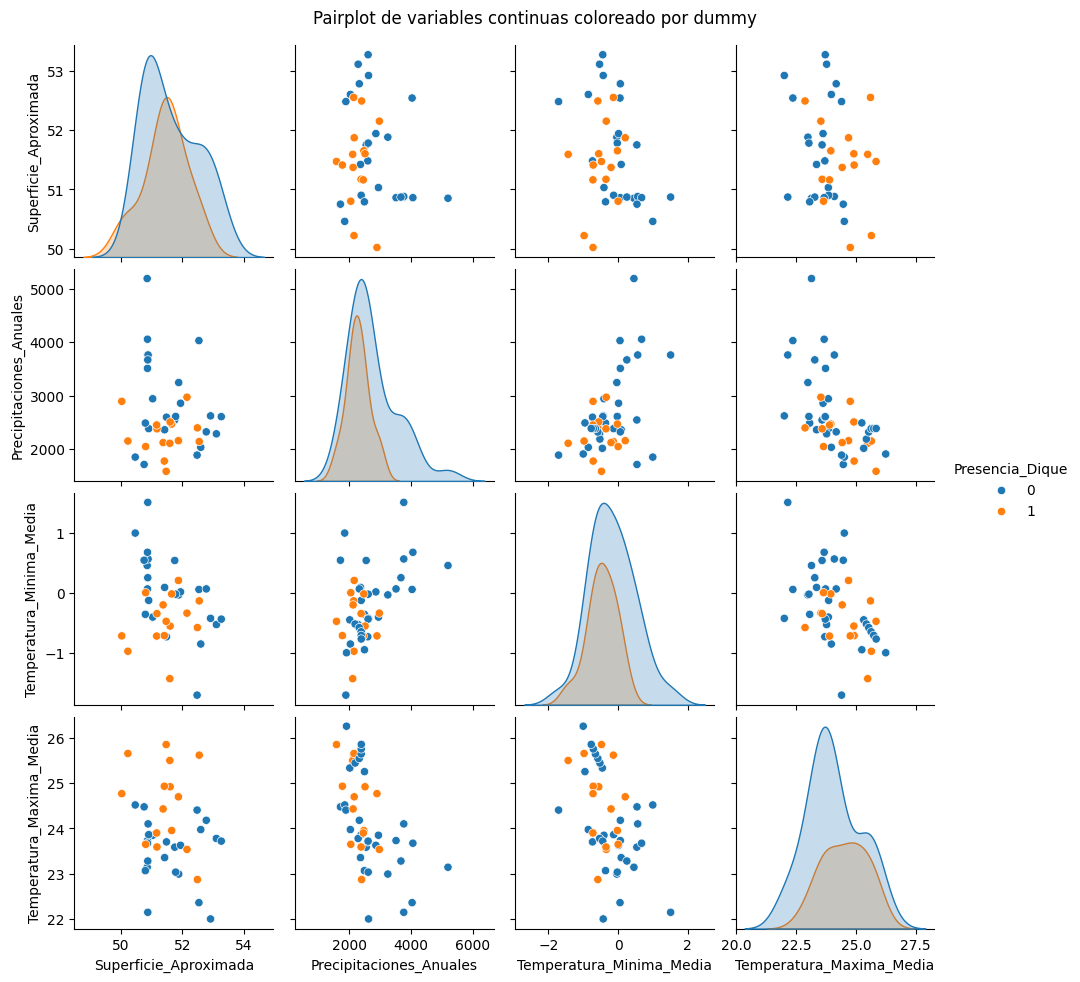

In [9]:
sns.pairplot(
    df,
    vars=["Superficie_Aproximada","Precipitaciones_Anuales","Temperatura_Minima_Media","Temperatura_Maxima_Media"],
    hue="Presencia_Dique",
    diag_kind="kde",
    height=2.4
)
plt.suptitle("Pairplot de variables continuas coloreado por dummy", y=1.02)
plt.show()

El color azul (Presencia_Dique = 0) y naranjo (Presencia_Dique = 1) se superponen casi por completo: a simple vista, la presencia de un dique no segmenta claramente los valores de las variables.

De este gráfico nos interesa más precisamente la fila/columna de superficie aproximada según la presencia o ausencia del dique, podemos visualizar que cuando el dique esta bloqueando el paso de algua, los valores del lago caburgua se concentran alrededor de 51.7 $km^2$. Por otra parte, cuando el dique no está implementado, las superficies del lago estan concentradas más a la izquierda sin embargo presentan valores más altos (valores finales más a la derecha).  

Lineas temporales:

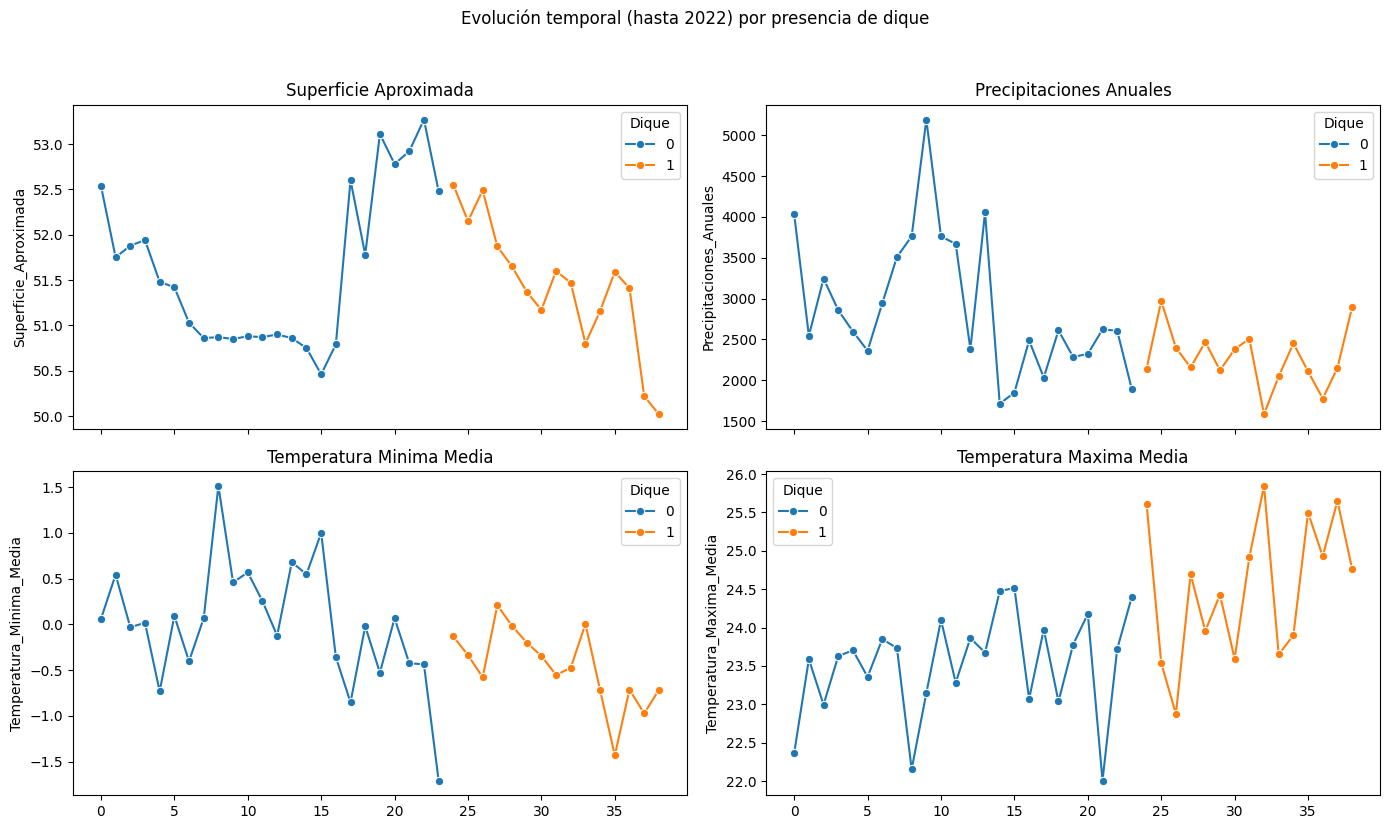

In [11]:
# --- 1. Filtrar hasta la observación 39 (0-based) ----------
df_sub = df.iloc[:39].copy()        # incluye filas 0…38

# ── Si el año ya es tu índice, comenta la línea siguiente
time_col = "Year"                   # <-- cámbialo a tu variable temporal
if "Year" not in df_sub.columns:
    df_sub[time_col] = df_sub.index  # usa el índice como eje-X

# --- 2. Configurar figure y ejes ---------------------------
vars_to_plot = [
    "Superficie_Aproximada",
    "Precipitaciones_Anuales",
    "Temperatura_Minima_Media",
    "Temperatura_Maxima_Media"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

# --- 3. Dibujar cada línea --------------------------------
for ax, var in zip(axes, vars_to_plot):
    sns.lineplot(
        data=df_sub,
        x=time_col,
        y=var,
        hue="Presencia_Dique",
        marker="o",
        ax=ax,
        palette={0: "#1f77b4", 1: "#ff7f0e"}  # opcional: colores fijos
    )
    ax.set_title(var.replace("_", " "))
    ax.set_xlabel("")                # limpia eje-X por estética
    ax.legend_.set_title("Dique")    # título de leyenda breve

# --- 4. Ajustes finales -----------------------------------
plt.suptitle("Evolución temporal (hasta 2022) por presencia de dique", y=1.03)
plt.tight_layout()
plt.show()

Observamos que:

1. Para la superficie, al momento de incluir el dique presenta una tendencia a la baja importante, pasando los valores mínimos históricos que había presentado el lago

2. Las precipitaciones anuales presentan fluctuaciones generalmente entre 1500 y 3000 mm.

3. La temperatura mínima promedio sostiene una tendencia (muy pequeña) a la baja y la temperatura máxima a la alta, esta última más notoria que el caso de la temperatura mínima.

Verificamos normalidad en la variable de respuesta

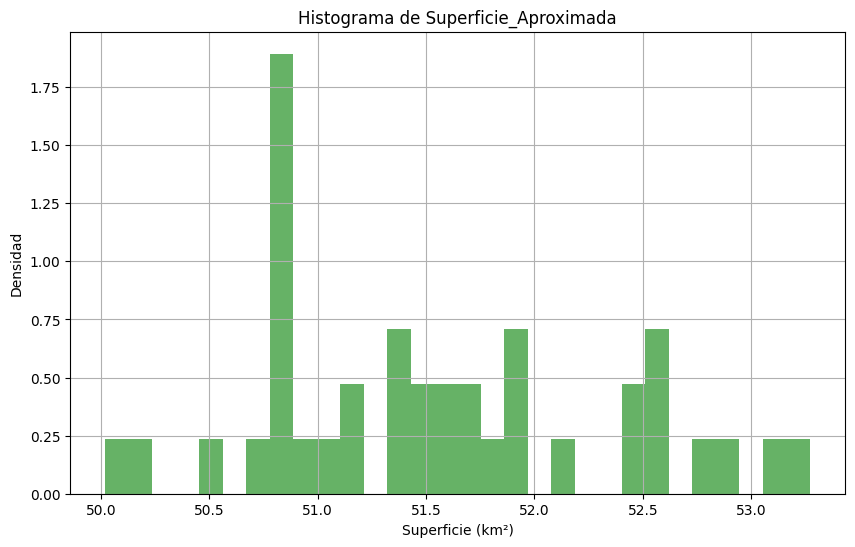

Normal fit:     µ=51.5536, σ=0.8071
Lognormal fit:  shape=0.0156, loc=0.0000, scale=51.5473
Exponencial fit: loc=0.0000, scale=51.5536
KS Normal:       D=0.1243, p=0.5419
KS Lognormal:    D=0.1241, p=0.5437
KS Exponencial:  D=0.6210, p=0.0000


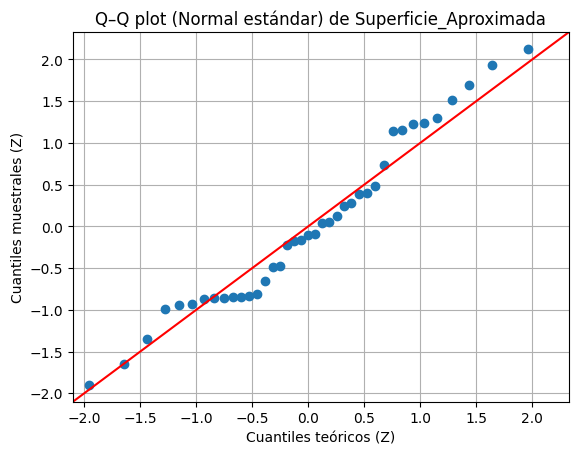

Shapiro–Wilk:    W=0.9608, p=0.1889


In [13]:
# — 1) Prepara los datos
data = df_sin_dique['Superficie_Aproximada'].dropna()

# — 2) Histograma
plt.figure(figsize=(10, 6))
plt.hist(data, bins=30, density=True, alpha=0.6, color='g')
plt.title('Histograma de Superficie_Aproximada')
plt.xlabel('Superficie (km²)')
plt.ylabel('Densidad')
plt.grid(True)
plt.show()

# — 3) Ajuste de parámetros

# 3.1 Normal
mu, sigma = st.norm.fit(data)
print(f"Normal fit:     µ={mu:.4f}, σ={sigma:.4f}")

# 3.2 Lognormal (forzando loc=0)
shape, loc_ln, scale_ln = st.lognorm.fit(data, floc=0)
print(f"Lognormal fit:  shape={shape:.4f}, loc={loc_ln:.4f}, scale={scale_ln:.4f}")

# 3.3 Exponencial (loc=0)
loc_exp, scale_exp = st.expon.fit(data, floc=0)
print(f"Exponencial fit: loc={loc_exp:.4f}, scale={scale_exp:.4f}")

# — 4) KS–test usando la CDF con los parámetros estimados

# Normal
ks_norm = st.kstest(data, lambda x: st.norm.cdf(x, loc=mu, scale=sigma))
print(f"KS Normal:       D={ks_norm.statistic:.4f}, p={ks_norm.pvalue:.4f}")

# Lognormal
ks_ln = st.kstest(data, lambda x: st.lognorm.cdf(x, shape, loc_ln, scale_ln))
print(f"KS Lognormal:    D={ks_ln.statistic:.4f}, p={ks_ln.pvalue:.4f}")

# Exponencial
ks_exp = st.kstest(data, lambda x: st.expon.cdf(x, loc_exp, scale_exp))
print(f"KS Exponencial:  D={ks_exp.statistic:.4f}, p={ks_exp.pvalue:.4f}")

# — 5) Q–Q plot correcto para la Normal estándar

# a) Estandariza los datos
data_std = (data - mu) / sigma

# b) Dibuja el Q–Q
fig = sm.qqplot(data_std, line='45', dist=st.norm, fit=False)
plt.title("Q–Q plot (Normal estándar) de Superficie_Aproximada")
plt.xlabel("Cuantiles teóricos (Z)")
plt.ylabel("Cuantiles muestrales (Z)")
plt.grid(True)
plt.show()

# — 6) Shapiro–Wilk como validación extra de normalidad
W, p_shapiro = st.shapiro(data)
print(f"Shapiro–Wilk:    W={W:.4f}, p={p_shapiro:.4f}")


Con un valor-p mayor a un nivel de significancia de 0.05 no se rechaza la hipótesis nula a favor de que las superficies del lago Caburgua entre 1984 y 2022 se distribuyen normal.

# Aplicación de los modelos

LSTM (SIN REINSTALACIÓN DEL DIQUE)

/tmp/ipython-input-14-2556344969.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_hist["Superficie_Aproximada"].fillna(mean_surface, inplace=True)


Secuencias totales: 32  |  Train: 25  |  Test: 7
Epoch 1/250
25/25 - 5s - 184ms/step - loss: 0.5427 - mae: 0.9668 - val_loss: 0.6014 - val_mae: 0.9767
Epoch 2/250
25/25 - 0s - 9ms/step - loss: 0.3730 - mae: 0.7169 - val_loss: 0.5596 - val_mae: 0.9034
Epoch 3/250
25/25 - 0s - 8ms/step - loss: 0.2824 - mae: 0.6006 - val_loss: 0.4951 - val_mae: 0.8092
Epoch 4/250
25/25 - 0s - 13ms/step - loss: 0.2175 - mae: 0.5249 - val_loss: 0.5006 - val_mae: 0.8262
Epoch 5/250
25/25 - 0s - 14ms/step - loss: 0.1532 - mae: 0.4256 - val_loss: 0.5433 - val_mae: 0.8973
Epoch 6/250
25/25 - 0s - 8ms/step - loss: 0.1382 - mae: 0.4258 - val_loss: 0.5206 - val_mae: 0.8708
Epoch 7/250
25/25 - 0s - 8ms/step - loss: 0.1046 - mae: 0.3634 - val_loss: 0.5584 - val_mae: 0.9230
Epoch 8/250
25/25 - 0s - 8ms/step - loss: 0.1019 - mae: 0.3513 - val_loss: 0.5037 - val_mae: 0.8482
Epoch 9/250
25/25 - 0s - 12ms/step - loss: 0.0998 - mae: 0.3321 - val_loss: 0.5248 - val_mae: 0.8751
Epoch 10/250
25/25 - 0s - 9ms/step - loss: 0.0

/tmp/ipython-input-14-2556344969.py:116: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_future[TARGET].fillna(mean_surface, inplace=True)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
Predicciones 2023‑2030 → predictions_2023_2030.csv
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


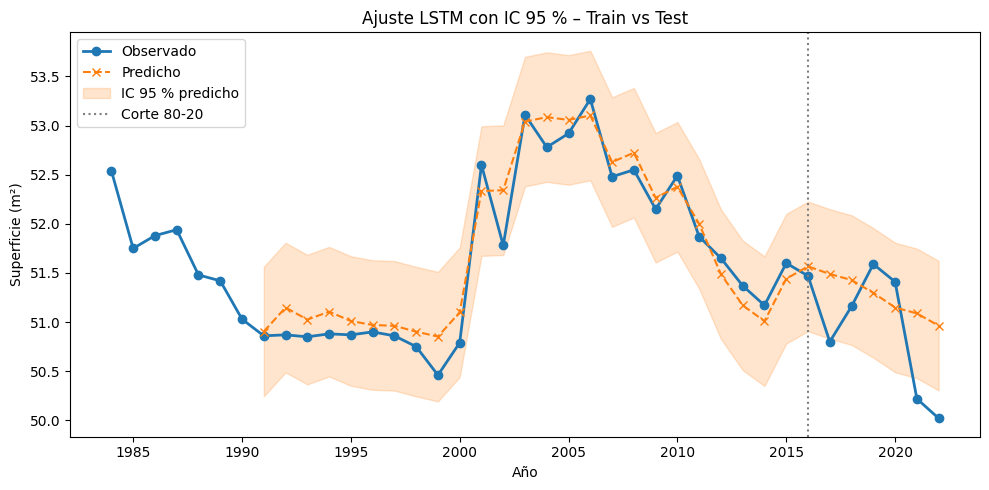

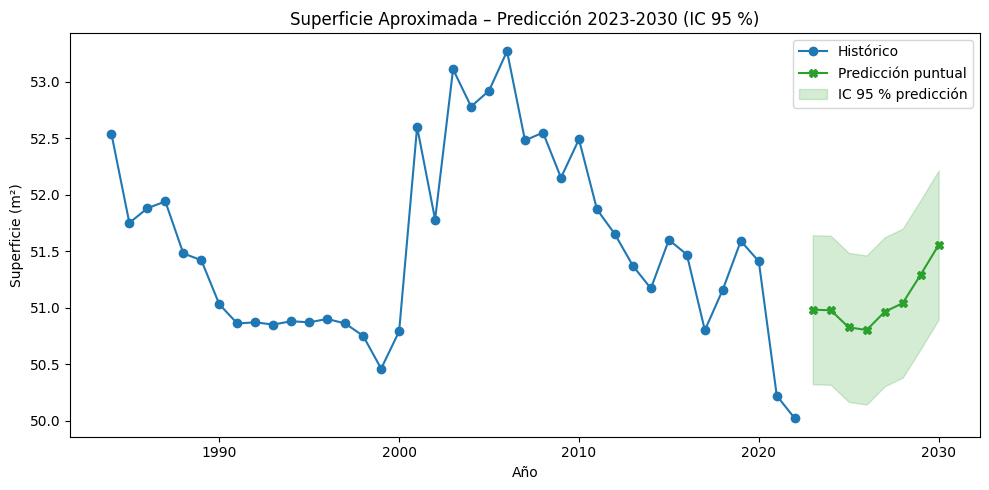

In [14]:
os.environ["PYTHONHASHSEED"] = str(SEED)
tf.keras.utils.set_random_seed(SEED)

# 2. Operaciones deterministas (para reproducibilidad)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
tf.config.experimental.enable_op_determinism()

# =====================================================================
# 2. Pre‑procesamiento
# =====================================================================
# Usamos datos con etiqueta (hasta 2022 incluido)
df = df_sin_dique.copy()
df["Año"] = df["Año"].astype(int)
df_hist = df[df["Año"] <= 2022].copy()

# Relleno básico de NA en superficie
mean_surface = df_hist["Superficie_Aproximada"].mean()
df_hist["Superficie_Aproximada"].fillna(mean_surface, inplace=True)

FEATURES = [
    "Precipitaciones_Anuales",
    "Temperatura_Minima_Media",
    "Temperatura_Maxima_Media",
    "Presencia_Dique",
]
TARGET = "Superficie_Aproximada"

# Escalado Min‑Max independiente
x_scaler, y_scaler = StandardScaler(), StandardScaler()
X_scaled = x_scaler.fit_transform(df_hist[FEATURES])
y_scaled = y_scaler.fit_transform(df_hist[[TARGET]])

# -------------------------------------------------------------
# Crear secuencias ventana deslizante
# -------------------------------------------------------------
WINDOW_SIZE = 7

def create_sequences(X, y, window):
    xs, ys = [], []
    for i in range(len(X) - window):
        xs.append(X[i : i + window])
        ys.append(y[i + window])
    return np.asarray(xs), np.asarray(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, WINDOW_SIZE)

# División 80‑20 (train‑test) manteniendo el orden temporal
SPLIT_RATIO = 0.8
split_idx = int(len(X_seq) * SPLIT_RATIO)
X_train, y_train = X_seq[:split_idx], y_seq[:split_idx]
X_test, y_test = X_seq[split_idx:], y_seq[split_idx:]

print(f"Secuencias totales: {len(X_seq)}  |  Train: {len(X_train)}  |  Test: {len(X_test)}")

# =====================================================================
# 3. Modelo LSTM
# =====================================================================

model = models.Sequential([
    layers.Input(shape=(WINDOW_SIZE, len(FEATURES))),
    layers.LSTM(
        64,
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=SEED),
        recurrent_initializer=tf.keras.initializers.Orthogonal(seed=SEED),
        return_sequences=True
    ),
    layers.Dropout(0.2, seed=SEED),
    layers.LSTM(
        32,
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=SEED),
        recurrent_initializer=tf.keras.initializers.Orthogonal(seed=SEED)
    ),
    layers.Dropout(0.2, seed=SEED),
    layers.Dense(1)
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(9e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae"]
)
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=250,
    batch_size=1,
    shuffle=False,
    callbacks=[callbacks.EarlyStopping(
        monitor="val_loss", patience=10, min_delta=5e-4,
        restore_best_weights=True)],
    verbose=2
)

# =====================================================================
# 4. Métricas en test y banda de error
# =====================================================================

y_pred_test = model.predict(X_test).flatten()
y_pred_test_inv = y_scaler.inverse_transform(y_pred_test.reshape(-1, 1)).flatten()
y_test_inv = y_scaler.inverse_transform(y_test).flatten()

mae_val = mean_absolute_error(y_test_inv, y_pred_test_inv)
rmse_val = mean_squared_error(y_test_inv, y_pred_test_inv)
print("\n≫ Métricas en test (20 %)")
print("MAE:", mae_val)
print("RMSE:", rmse_val)

# Factor para IC 95 % asumiendo normalidad
Z = 1.96

# =====================================================================
# 5. Predicción 2023‑2030
# =====================================================================

START_PRED = 2023                       # primer año que quieres pronosticar
df_future = df[df["Año"] >= START_PRED - WINDOW_SIZE].copy().reset_index(drop=True)
df_future[TARGET].fillna(mean_surface, inplace=True)

X_future_scaled = x_scaler.transform(df_future[FEATURES])
X_future_seq, _ = create_sequences(X_future_scaled, np.zeros_like(X_future_scaled[:, :1]), WINDOW_SIZE)

preds_future_inv = y_scaler.inverse_transform(model.predict(X_future_seq)).flatten()
future_years = df_future["Año"].iloc[WINDOW_SIZE:].values

df_preds = pd.DataFrame({"Año": future_years, "Superficie_Predicha": preds_future_inv})
df_preds.to_csv("predictions_2023_2030.csv", index=False)
print("Predicciones 2023‑2030 → predictions_2023_2030.csv")

# =====================================================================
# 6. Gráficos con bandas de confianza ±1.96·RMSE
# =====================================================================
try:
    import matplotlib.pyplot as plt

    # --- 6.1 Train/Test con IC ---
    years_hist = df_hist["Año"].iloc[WINDOW_SIZE:]
    preds_hist_inv = y_scaler.inverse_transform(model.predict(X_seq)).flatten()
    ci_upper_hist = preds_hist_inv + Z * rmse_val
    ci_lower_hist = preds_hist_inv - Z * rmse_val

    split_year = years_hist.iloc[split_idx]

    plt.figure(figsize=(10, 5))
    plt.plot(df_hist["Año"], df_hist[TARGET], label="Observado", marker="o", linewidth=2)
    plt.plot(years_hist, preds_hist_inv, label="Predicho", linestyle="--", marker="x", color="tab:orange")
    plt.fill_between(years_hist, ci_lower_hist, ci_upper_hist, color="tab:orange", alpha=0.2, label="IC 95 % predicho")
    plt.axvline(x=split_year, color="gray", linestyle=":", label="Corte 80‑20")
    plt.title("Ajuste LSTM con IC 95 % – Train vs Test")
    plt.xlabel("Año")
    plt.ylabel("Superficie (m²)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- 6.2 Futuro con IC ---
    ci_upper_future = preds_future_inv + Z * rmse_val
    ci_lower_future = preds_future_inv - Z * rmse_val

    plt.figure(figsize=(10, 5))
    plt.plot(df["Año"], df[TARGET], label="Histórico", marker="o")
    plt.plot(df_preds["Año"], df_preds["Superficie_Predicha"], label="Predicción puntual", marker="X", color="tab:green")
    plt.fill_between(df_preds["Año"], ci_lower_future, ci_upper_future, color="tab:green", alpha=0.2, label="IC 95 % predicción")
    plt.title("Superficie Aproximada – Predicción 2023‑2030 (IC 95 %)")
    plt.xlabel("Año")
    plt.ylabel("Superficie (m²)")
    plt.legend()
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib no instalado: gráficos omitidos.")

LSTM con restauración del dique en 2026

Secuencias totales: 32  |  Train: 25  |  Test: 7
Epoch 1/250


/tmp/ipython-input-15-2496661102.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_hist["Superficie_Aproximada"].fillna(mean_surface, inplace=True)


25/25 - 5s - 203ms/step - loss: 0.5427 - mae: 0.9668 - val_loss: 0.6014 - val_mae: 0.9767
Epoch 2/250
25/25 - 0s - 8ms/step - loss: 0.3730 - mae: 0.7169 - val_loss: 0.5596 - val_mae: 0.9034
Epoch 3/250
25/25 - 1s - 22ms/step - loss: 0.2824 - mae: 0.6006 - val_loss: 0.4951 - val_mae: 0.8092
Epoch 4/250
25/25 - 0s - 9ms/step - loss: 0.2175 - mae: 0.5249 - val_loss: 0.5006 - val_mae: 0.8262
Epoch 5/250
25/25 - 0s - 11ms/step - loss: 0.1532 - mae: 0.4256 - val_loss: 0.5433 - val_mae: 0.8973
Epoch 6/250
25/25 - 1s - 27ms/step - loss: 0.1382 - mae: 0.4258 - val_loss: 0.5206 - val_mae: 0.8708
Epoch 7/250
25/25 - 0s - 14ms/step - loss: 0.1046 - mae: 0.3634 - val_loss: 0.5584 - val_mae: 0.9230
Epoch 8/250
25/25 - 0s - 16ms/step - loss: 0.1019 - mae: 0.3513 - val_loss: 0.5037 - val_mae: 0.8482
Epoch 9/250
25/25 - 0s - 18ms/step - loss: 0.0998 - mae: 0.3321 - val_loss: 0.5248 - val_mae: 0.8751
Epoch 10/250
25/25 - 1s - 28ms/step - loss: 0.0973 - mae: 0.3495 - val_loss: 0.4878 - val_mae: 0.8263
Ep

/tmp/ipython-input-15-2496661102.py:116: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_future[TARGET].fillna(mean_surface, inplace=True)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
Predicciones 2023‑2030 → predictions_2023_2030.csv
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


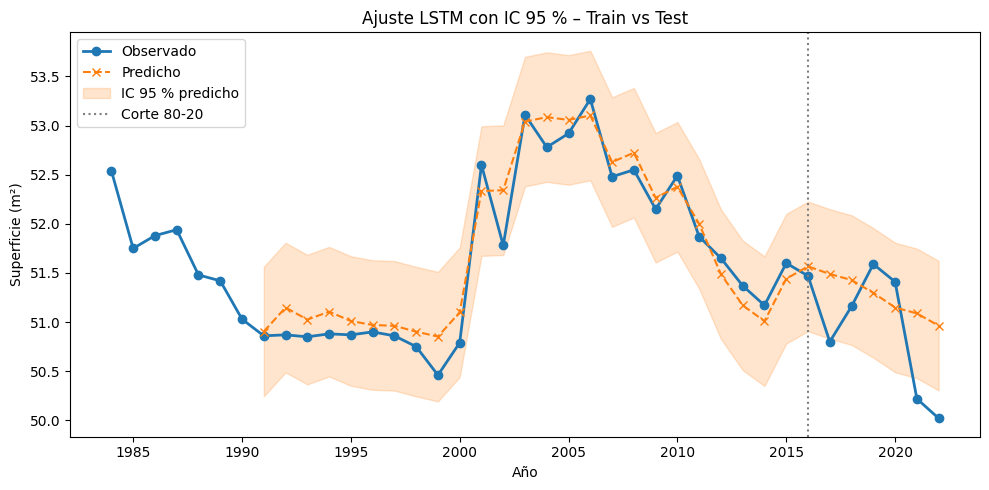

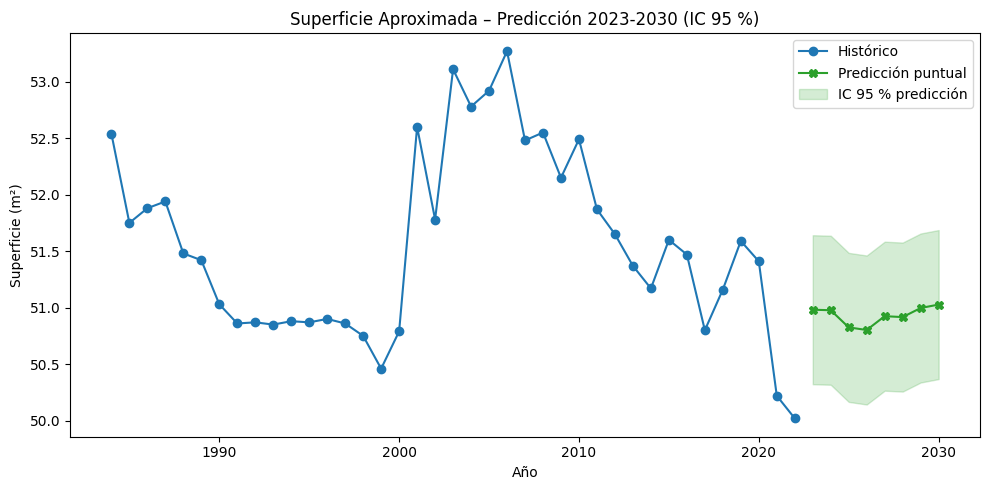

In [15]:
os.environ["PYTHONHASHSEED"] = str(SEED)          # Hash de Python
tf.keras.utils.set_random_seed(SEED)              # Python + NumPy + TF :contentReference[oaicite:3]{index=3}

# 2. Operaciones deterministas (⚠ puede ralentizar ~5-15 %)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
tf.config.experimental.enable_op_determinism()

# =====================================================================
# 2. Pre‑procesamiento
# =====================================================================
# Usamos datos con etiqueta (hasta 2022 incluido)
df = df_con_dique.copy()
df["Año"] = df["Año"].astype(int)
df_hist = df[df["Año"] <= 2022].copy()

# Relleno básico de NA en superficie
mean_surface = df_hist["Superficie_Aproximada"].mean()
df_hist["Superficie_Aproximada"].fillna(mean_surface, inplace=True)

FEATURES = [
    "Precipitaciones_Anuales",
    "Temperatura_Minima_Media",
    "Temperatura_Maxima_Media",
    "Presencia_Dique",
]
TARGET = "Superficie_Aproximada"

# Escalado Min‑Max independiente
x_scaler, y_scaler = StandardScaler(), StandardScaler()
X_scaled = x_scaler.fit_transform(df_hist[FEATURES])
y_scaled = y_scaler.fit_transform(df_hist[[TARGET]])

# -------------------------------------------------------------
# Crear secuencias ventana deslizante
# -------------------------------------------------------------
WINDOW_SIZE = 7

def create_sequences(X, y, window):
    xs, ys = [], []
    for i in range(len(X) - window):
        xs.append(X[i : i + window])
        ys.append(y[i + window])
    return np.asarray(xs), np.asarray(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, WINDOW_SIZE)

# División 80‑20 (train‑test) manteniendo el orden temporal
SPLIT_RATIO = 0.8
split_idx = int(len(X_seq) * SPLIT_RATIO)
X_train, y_train = X_seq[:split_idx], y_seq[:split_idx]
X_test, y_test = X_seq[split_idx:], y_seq[split_idx:]

print(f"Secuencias totales: {len(X_seq)}  |  Train: {len(X_train)}  |  Test: {len(X_test)}")

# =====================================================================
# 3. Modelo LSTM
# =====================================================================

model = models.Sequential([
    layers.Input(shape=(WINDOW_SIZE, len(FEATURES))),
    layers.LSTM(
        64,
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=SEED),
        recurrent_initializer=tf.keras.initializers.Orthogonal(seed=SEED),
        return_sequences=True
    ),
    layers.Dropout(0.2, seed=SEED),
    layers.LSTM(
        32,
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=SEED),
        recurrent_initializer=tf.keras.initializers.Orthogonal(seed=SEED)
    ),
    layers.Dropout(0.2, seed=SEED),
    layers.Dense(1)
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(9e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae"]
)
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=250,
    batch_size=1,
    shuffle=False,
    callbacks=[callbacks.EarlyStopping(
        monitor="val_loss", patience=10, min_delta=5e-4,
        restore_best_weights=True)],
    verbose=2
)

# =====================================================================
# 4. Métricas en test y banda de error
# =====================================================================

y_pred_test = model.predict(X_test).flatten()
y_pred_test_inv = y_scaler.inverse_transform(y_pred_test.reshape(-1, 1)).flatten()
y_test_inv = y_scaler.inverse_transform(y_test).flatten()

mae_val = mean_absolute_error(y_test_inv, y_pred_test_inv)
rmse_val = mean_squared_error(y_test_inv, y_pred_test_inv)
print("\n≫ Métricas en test (20 %)")
print("MAE:", mae_val)
print("RMSE:", rmse_val)

# Factor para IC 95 % asumiendo normalidad
Z = 1.96

# =====================================================================
# 5. Predicción 2023‑2030
# =====================================================================

START_PRED = 2023                       # primer año que quieres pronosticar
df_future = df[df["Año"] >= START_PRED - WINDOW_SIZE].copy().reset_index(drop=True)
df_future[TARGET].fillna(mean_surface, inplace=True)

X_future_scaled = x_scaler.transform(df_future[FEATURES])
X_future_seq, _ = create_sequences(X_future_scaled, np.zeros_like(X_future_scaled[:, :1]), WINDOW_SIZE)

preds_future_inv = y_scaler.inverse_transform(model.predict(X_future_seq)).flatten()
future_years = df_future["Año"].iloc[WINDOW_SIZE:].values

df_preds = pd.DataFrame({"Año": future_years, "Superficie_Predicha": preds_future_inv})
df_preds.to_csv("predictions_2023_2030.csv", index=False)
print("Predicciones 2023‑2030 → predictions_2023_2030.csv")

# =====================================================================
# 6. Gráficos con bandas de confianza ±1.96·RMSE
# =====================================================================
try:
    import matplotlib.pyplot as plt

    # --- 6.1 Train/Test con IC ---
    years_hist = df_hist["Año"].iloc[WINDOW_SIZE:]
    preds_hist_inv = y_scaler.inverse_transform(model.predict(X_seq)).flatten()
    ci_upper_hist = preds_hist_inv + Z * rmse_val
    ci_lower_hist = preds_hist_inv - Z * rmse_val

    split_year = years_hist.iloc[split_idx]

    plt.figure(figsize=(10, 5))
    plt.plot(df_hist["Año"], df_hist[TARGET], label="Observado", marker="o", linewidth=2)
    plt.plot(years_hist, preds_hist_inv, label="Predicho", linestyle="--", marker="x", color="tab:orange")
    plt.fill_between(years_hist, ci_lower_hist, ci_upper_hist, color="tab:orange", alpha=0.2, label="IC 95 % predicho")
    plt.axvline(x=split_year, color="gray", linestyle=":", label="Corte 80‑20")
    plt.title("Ajuste LSTM con IC 95 % – Train vs Test")
    plt.xlabel("Año")
    plt.ylabel("Superficie (m²)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- 6.2 Futuro con IC ---
    ci_upper_future = preds_future_inv + Z * rmse_val
    ci_lower_future = preds_future_inv - Z * rmse_val

    plt.figure(figsize=(10, 5))
    plt.plot(df["Año"], df[TARGET], label="Histórico", marker="o")
    plt.plot(df_preds["Año"], df_preds["Superficie_Predicha"], label="Predicción puntual", marker="X", color="tab:green")
    plt.fill_between(df_preds["Año"], ci_lower_future, ci_upper_future, color="tab:green", alpha=0.2, label="IC 95 % predicción")
    plt.title("Superficie Aproximada – Predicción 2023‑2030 (IC 95 %)")
    plt.xlabel("Año")
    plt.ylabel("Superficie (m²)")
    plt.legend()
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib no instalado: gráficos omitidos.")

Ahora MODELO Random Forest (sin reinstalación del dique)

/tmp/ipython-input-16-966511184.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_hist["Superficie_Aproximada"].fillna(mean_surface, inplace=True)


Secuencias totales: 32  |  Train: 25  |  Test: 7

≫ Métricas en test (20 %)
MAE : 1.039
RMSE: 1.480
Predicciones 2023-2030 → predictions_2023_2030_rf.csv


/tmp/ipython-input-16-966511184.py:96: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_future[TARGET].fillna(mean_surface, inplace=True)


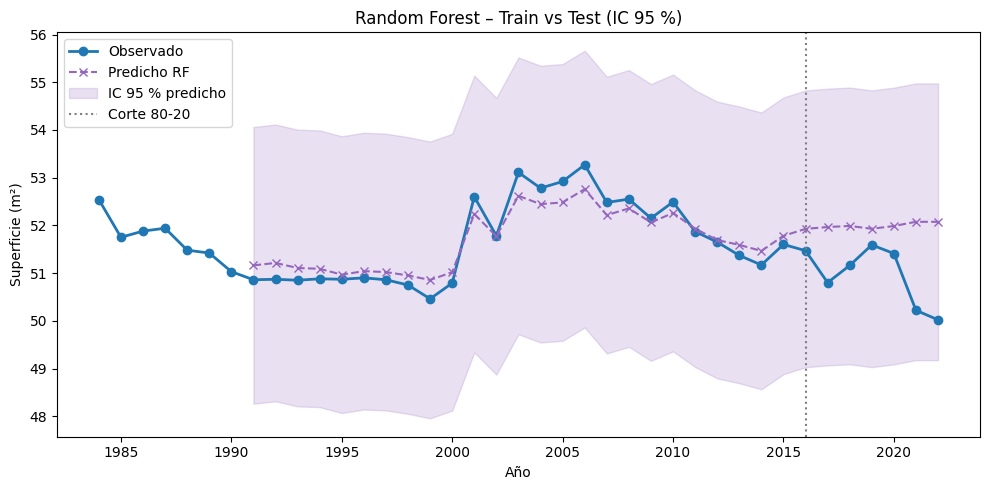

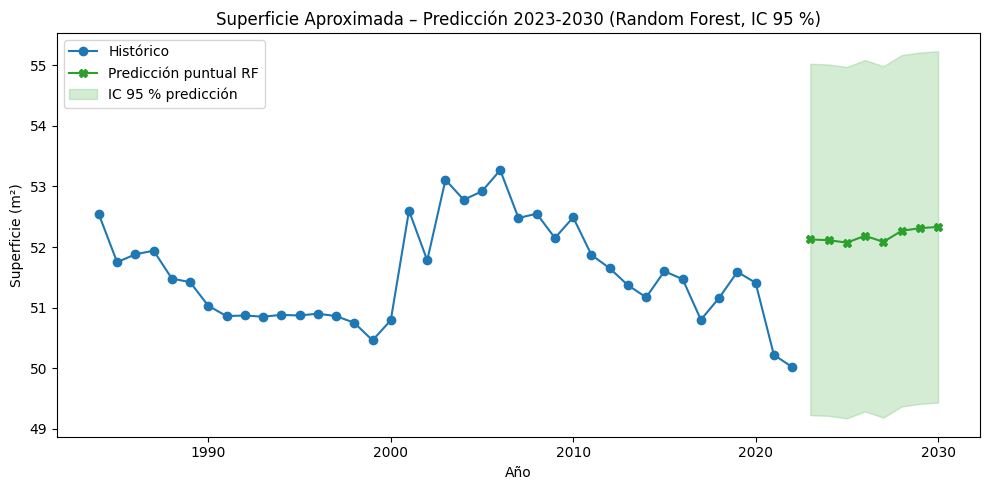

In [16]:
# =====================================================================

# Reproducibilidad total
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)

# =====================================================================
# 2. Pre‑procesamiento
# =====================================================================
# Usamos datos con etiqueta (hasta 2022 incluido)
df = df_sin_dique.copy()
df["Año"] = df["Año"].astype(int)
df_hist = df[df["Año"] <= 2022].copy()

# Relleno básico de NA en superficie
mean_surface = df_hist["Superficie_Aproximada"].mean()
df_hist["Superficie_Aproximada"].fillna(mean_surface, inplace=True)

FEATURES = [
    "Precipitaciones_Anuales",
    "Temperatura_Minima_Media",
    "Temperatura_Maxima_Media",
    "Presencia_Dique",
]
TARGET = "Superficie_Aproximada"

# Escalado Min‑Max independiente
x_scaler, y_scaler = StandardScaler(), StandardScaler()
X_scaled = x_scaler.fit_transform(df_hist[FEATURES])
y_scaled = y_scaler.fit_transform(df_hist[[TARGET]])

# -------------------------------------------------------------
# Crear secuencias ventana deslizante
# -------------------------------------------------------------
WINDOW_SIZE = 7

def create_sequences(X, y, window):
    xs, ys = [], []
    for i in range(len(X) - window):
        xs.append(X[i : i + window])
        ys.append(y[i + window])
    return np.asarray(xs), np.asarray(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, WINDOW_SIZE)

# ---------------------------------------------------------------------
# 2. Aplanar las ventanas (Random Forest espera 2-D)
# ---------------------------------------------------------------------
X_seq_flat = X_seq.reshape(X_seq.shape[0], -1)   # (n_seq, window * n_features)
y_seq_flat = y_seq.flatten()

# Split 80-20 manteniendo la misma lógica temporal
split_idx = int(len(X_seq_flat) * SPLIT_RATIO)
X_train, y_train = X_seq_flat[:split_idx], y_seq_flat[:split_idx]
X_test,  y_test  = X_seq_flat[split_idx:], y_seq_flat[split_idx:]

print(f"Secuencias totales: {len(X_seq_flat)}  |  Train: {len(X_train)}  |  Test: {len(X_test)}")

# =====================================================================
# 3. Modelo Random Forest
# =====================================================================
rf = RandomForestRegressor(
    n_estimators=500,          # prueba 200-1000 según tu tiempo de cómputo
    max_depth=None,           # None = nodos hasta que no puedan dividirse más
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",      # √p suele rendir bien
    bootstrap=True,
    random_state=SEED,
    n_jobs=-1                 # paraleliza en todos los núcleos
)

rf.fit(X_train, y_train)

# =====================================================================
# 4. Métricas en test e IC
# =====================================================================
y_pred_test = rf.predict(X_test)
y_pred_test_inv = y_scaler.inverse_transform(y_pred_test.reshape(-1, 1)).flatten()
y_test_inv      = y_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

mae_val  = mean_absolute_error(y_test_inv, y_pred_test_inv)
rmse_val = mean_squared_error(y_test_inv, y_pred_test_inv)  # √MSE

print("\n≫ Métricas en test (20 %)")
print(f"MAE : {mae_val:.3f}")
print(f"RMSE: {rmse_val:.3f}")

Z = 1.96   # para banda IC 95 %

# =====================================================================
# 5. Predicción 2023-2030
# =====================================================================
df_future = df[df["Año"] >= START_PRED - WINDOW_SIZE].copy().reset_index(drop=True)
df_future[TARGET].fillna(mean_surface, inplace=True)

X_future_scaled = x_scaler.transform(df_future[FEATURES])
X_future_seq, _ = create_sequences(X_future_scaled, np.zeros_like(X_future_scaled[:, :1]), WINDOW_SIZE)
X_future_flat   = X_future_seq.reshape(X_future_seq.shape[0], -1)

preds_future_inv = y_scaler.inverse_transform(rf.predict(X_future_flat).reshape(-1, 1)).flatten()
future_years     = df_future["Año"].iloc[WINDOW_SIZE:].values

df_preds = pd.DataFrame({"Año": future_years, "Superficie_Predicha": preds_future_inv})
df_preds.to_csv("predictions_2023_2030_rf.csv", index=False)
print("Predicciones 2023-2030 → predictions_2023_2030_rf.csv")

# =====================================================================
# 6. Gráficos con IC ±1.96·RMSE  (idénticos a tu bloque actual)
# =====================================================================
try:
    import matplotlib.pyplot as plt

    # --- 6.1 Train/Test con IC ---
    years_hist       = df_hist["Año"].iloc[WINDOW_SIZE:]
    preds_hist_inv   = y_scaler.inverse_transform(rf.predict(X_seq_flat).reshape(-1,1)).flatten()
    ci_upper_hist    = preds_hist_inv + Z * rmse_val
    ci_lower_hist    = preds_hist_inv - Z * rmse_val
    split_year       = years_hist.iloc[split_idx]

    plt.figure(figsize=(10, 5))
    plt.plot(df_hist["Año"], df_hist[TARGET], label="Observado", marker="o", linewidth=2)
    plt.plot(years_hist, preds_hist_inv, label="Predicho RF", linestyle="--", marker="x", color="tab:purple")
    plt.fill_between(years_hist, ci_lower_hist, ci_upper_hist, color="tab:purple", alpha=0.2,
                     label="IC 95 % predicho")
    plt.axvline(x=split_year, color="gray", linestyle=":", label="Corte 80-20")
    plt.title("Random Forest – Train vs Test (IC 95 %)")
    plt.xlabel("Año"); plt.ylabel("Superficie (m²)"); plt.legend(); plt.tight_layout(); plt.show()

    # --- 6.2 Futuro con IC ---
    ci_upper_future = preds_future_inv + Z * rmse_val
    ci_lower_future = preds_future_inv - Z * rmse_val

    plt.figure(figsize=(10, 5))
    plt.plot(df["Año"], df[TARGET], label="Histórico", marker="o")
    plt.plot(df_preds["Año"], df_preds["Superficie_Predicha"],
             label="Predicción puntual RF", marker="X", color="tab:green")
    plt.fill_between(df_preds["Año"], ci_lower_future, ci_upper_future,
                     color="tab:green", alpha=0.2, label="IC 95 % predicción")
    plt.title("Superficie Aproximada – Predicción 2023-2030 (Random Forest, IC 95 %)")
    plt.xlabel("Año"); plt.ylabel("Superficie (m²)"); plt.legend(); plt.tight_layout(); plt.show()

except ImportError:
    print("matplotlib no instalado: gráficos omitidos.")

Random forest con reinstalación del dique

/tmp/ipython-input-17-1807563531.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_hist["Superficie_Aproximada"].fillna(mean_surface, inplace=True)


Secuencias totales: 32  |  Train: 25  |  Test: 7

≫ Métricas en test (20 %)
MAE : 1.039
RMSE: 1.480


/tmp/ipython-input-17-1807563531.py:96: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_future[TARGET].fillna(mean_surface, inplace=True)


Predicciones 2023-2030 → predictions_2023_2030_rf.csv


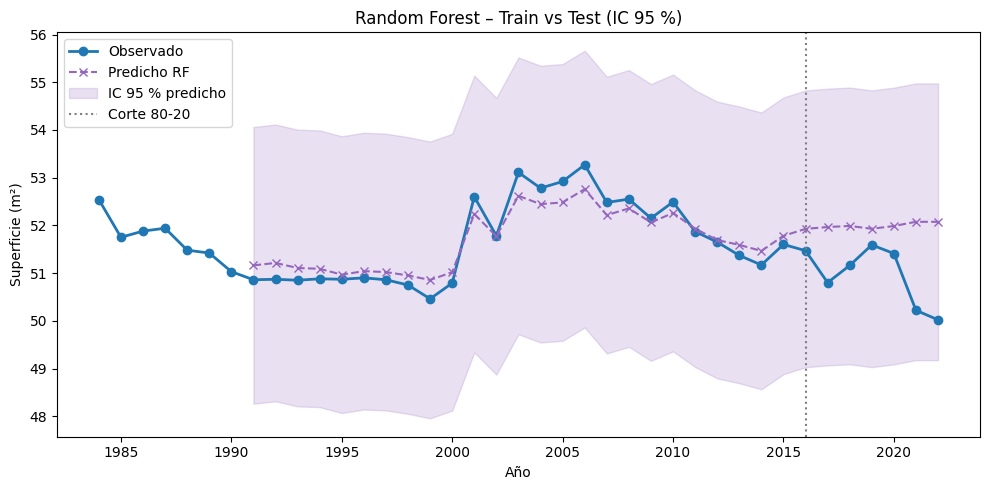

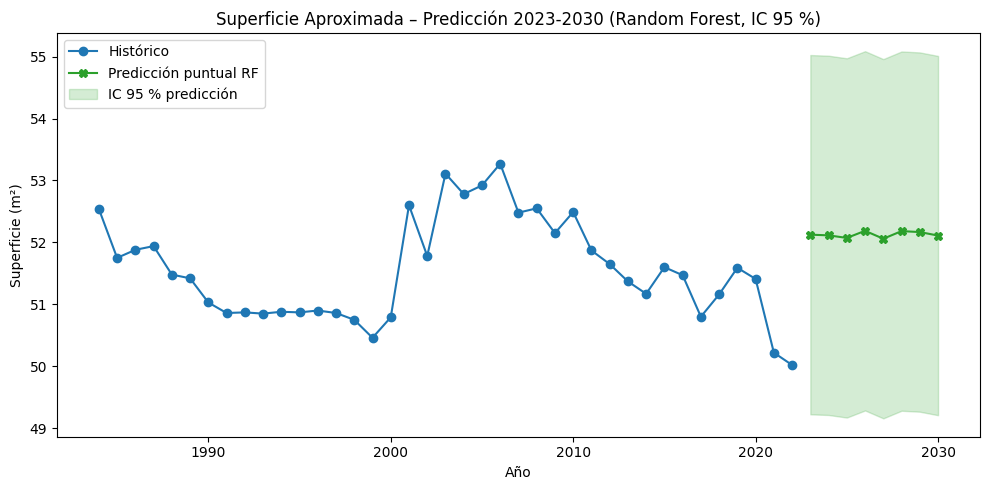

In [17]:
# =====================================================================

# Reproducibilidad total
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)

# =====================================================================
# 2. Pre‑procesamiento
# =====================================================================
# Usamos datos con etiqueta (hasta 2022 incluido)
df = df_con_dique.copy()
df["Año"] = df["Año"].astype(int)
df_hist = df[df["Año"] <= 2022].copy()

# Relleno básico de NA en superficie
mean_surface = df_hist["Superficie_Aproximada"].mean()
df_hist["Superficie_Aproximada"].fillna(mean_surface, inplace=True)

FEATURES = [
    "Precipitaciones_Anuales",
    "Temperatura_Minima_Media",
    "Temperatura_Maxima_Media",
    "Presencia_Dique",
]
TARGET = "Superficie_Aproximada"

# Escalado Min‑Max independiente
x_scaler, y_scaler = StandardScaler(), StandardScaler()
X_scaled = x_scaler.fit_transform(df_hist[FEATURES])
y_scaled = y_scaler.fit_transform(df_hist[[TARGET]])

# -------------------------------------------------------------
# Crear secuencias ventana deslizante
# -------------------------------------------------------------
WINDOW_SIZE = 7

def create_sequences(X, y, window):
    xs, ys = [], []
    for i in range(len(X) - window):
        xs.append(X[i : i + window])
        ys.append(y[i + window])
    return np.asarray(xs), np.asarray(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, WINDOW_SIZE)

# ---------------------------------------------------------------------
# 2. Aplanar las ventanas (Random Forest espera 2-D)
# ---------------------------------------------------------------------
X_seq_flat = X_seq.reshape(X_seq.shape[0], -1)   # (n_seq, window * n_features)
y_seq_flat = y_seq.flatten()

# Split 80-20 manteniendo la misma lógica temporal
split_idx = int(len(X_seq_flat) * SPLIT_RATIO)
X_train, y_train = X_seq_flat[:split_idx], y_seq_flat[:split_idx]
X_test,  y_test  = X_seq_flat[split_idx:], y_seq_flat[split_idx:]

print(f"Secuencias totales: {len(X_seq_flat)}  |  Train: {len(X_train)}  |  Test: {len(X_test)}")

# =====================================================================
# 3. Modelo Random Forest
# =====================================================================
rf = RandomForestRegressor(
    n_estimators=500,          # prueba 200-1000 según tu tiempo de cómputo
    max_depth=None,           # None = nodos hasta que no puedan dividirse más
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",      # √p suele rendir bien
    bootstrap=True,
    random_state=SEED,
    n_jobs=-1                 # paraleliza en todos los núcleos
)

rf.fit(X_train, y_train)

# =====================================================================
# 4. Métricas en test e IC
# =====================================================================
y_pred_test = rf.predict(X_test)
y_pred_test_inv = y_scaler.inverse_transform(y_pred_test.reshape(-1, 1)).flatten()
y_test_inv      = y_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

mae_val  = mean_absolute_error(y_test_inv, y_pred_test_inv)
rmse_val = mean_squared_error(y_test_inv, y_pred_test_inv)  # √MSE

print("\n≫ Métricas en test (20 %)")
print(f"MAE : {mae_val:.3f}")
print(f"RMSE: {rmse_val:.3f}")

Z = 1.96   # para banda IC 95 %

# =====================================================================
# 5. Predicción 2023-2030
# =====================================================================
df_future = df[df["Año"] >= START_PRED - WINDOW_SIZE].copy().reset_index(drop=True)
df_future[TARGET].fillna(mean_surface, inplace=True)

X_future_scaled = x_scaler.transform(df_future[FEATURES])
X_future_seq, _ = create_sequences(X_future_scaled, np.zeros_like(X_future_scaled[:, :1]), WINDOW_SIZE)
X_future_flat   = X_future_seq.reshape(X_future_seq.shape[0], -1)

preds_future_inv = y_scaler.inverse_transform(rf.predict(X_future_flat).reshape(-1, 1)).flatten()
future_years     = df_future["Año"].iloc[WINDOW_SIZE:].values

df_preds = pd.DataFrame({"Año": future_years, "Superficie_Predicha": preds_future_inv})
df_preds.to_csv("predictions_2023_2030_rf.csv", index=False)
print("Predicciones 2023-2030 → predictions_2023_2030_rf.csv")

# =====================================================================
# 6. Gráficos con IC ±1.96·RMSE  (idénticos a tu bloque actual)
# =====================================================================
try:
    import matplotlib.pyplot as plt

    # --- 6.1 Train/Test con IC ---
    years_hist       = df_hist["Año"].iloc[WINDOW_SIZE:]
    preds_hist_inv   = y_scaler.inverse_transform(rf.predict(X_seq_flat).reshape(-1,1)).flatten()
    ci_upper_hist    = preds_hist_inv + Z * rmse_val
    ci_lower_hist    = preds_hist_inv - Z * rmse_val
    split_year       = years_hist.iloc[split_idx]

    plt.figure(figsize=(10, 5))
    plt.plot(df_hist["Año"], df_hist[TARGET], label="Observado", marker="o", linewidth=2)
    plt.plot(years_hist, preds_hist_inv, label="Predicho RF", linestyle="--", marker="x", color="tab:purple")
    plt.fill_between(years_hist, ci_lower_hist, ci_upper_hist, color="tab:purple", alpha=0.2,
                     label="IC 95 % predicho")
    plt.axvline(x=split_year, color="gray", linestyle=":", label="Corte 80-20")
    plt.title("Random Forest – Train vs Test (IC 95 %)")
    plt.xlabel("Año"); plt.ylabel("Superficie (m²)"); plt.legend(); plt.tight_layout(); plt.show()

    # --- 6.2 Futuro con IC ---
    ci_upper_future = preds_future_inv + Z * rmse_val
    ci_lower_future = preds_future_inv - Z * rmse_val

    plt.figure(figsize=(10, 5))
    plt.plot(df["Año"], df[TARGET], label="Histórico", marker="o")
    plt.plot(df_preds["Año"], df_preds["Superficie_Predicha"],
             label="Predicción puntual RF", marker="X", color="tab:green")
    plt.fill_between(df_preds["Año"], ci_lower_future, ci_upper_future,
                     color="tab:green", alpha=0.2, label="IC 95 % predicción")
    plt.title("Superficie Aproximada – Predicción 2023-2030 (Random Forest, IC 95 %)")
    plt.xlabel("Año"); plt.ylabel("Superficie (m²)"); plt.legend(); plt.tight_layout(); plt.show()

except ImportError:
    print("matplotlib no instalado: gráficos omitidos.")

Modelo TCN (sin reinstalación del dique)

/tmp/ipython-input-18-145997540.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_hist["Superficie_Aproximada"].fillna(mean_surface, inplace=True)


Secuencias totales: 33  |  Train: 26  |  Test: 7


Model: "TCN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 6, 4)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 6, 32)     │        416 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 6, 32)     │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 6, 32)     │      3,104 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 6, 32)     │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 6, 32)     │        160 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 6, 32)     │          0 │ dropout_5[0][0],  │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 6, 32)     │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 6, 32)     │      3,104 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 6, 32)     │          0 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 6, 32)     │      3,104 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 6, 32)     │          0 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 6, 32)     │          0 │ dropout_7[0][0],  │
│                     │                   │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 6, 32)     │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 6, 32)     │      3,104 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 6, 32)     │          0 │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 6, 32)     │      3,104 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 6, 32)     │          0 │ conv1d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 6, 32)     │          0 │ dropout_9[0][0],  │
│                     │                   │            │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 6, 32)     │          0 │ add_2[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 6, 32)     │      3,104 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 22,337 (87.25 KB)

...

 Non-trainable params: 0 (0.00 B)

Epoch 1/250
26/26 - 12s - 452ms/step - loss: 0.5901 - mae: 0.9666 - val_loss: 0.4515 - val_mae: 0.7678
Epoch 2/250
26/26 - 1s - 28ms/step - loss: 0.4019 - mae: 0.7795 - val_loss: 0.5534 - val_mae: 0.8988
Epoch 3/250
26/26 - 0s - 14ms/step - loss: 0.3254 - mae: 0.6981 - val_loss: 0.5309 - val_mae: 0.8577
Epoch 4/250
26/26 - 0s - 8ms/step - loss: 0.2721 - mae: 0.6031 - val_loss: 0.4916 - val_mae: 0.8007
Epoch 5/250
26/26 - 0s - 11ms/step - loss: 0.2166 - mae: 0.5549 - val_loss: 0.4830 - val_mae: 0.7949
Epoch 6/250
26/26 - 0s - 7ms/step - loss: 0.1973 - mae: 0.5409 - val_loss: 0.4528 - val_mae: 0.7644
Epoch 7/250
26/26 - 0s - 13ms/step - loss: 0.1871 - mae: 0.5232 - val_loss: 0.4446 - val_mae: 0.7534
Epoch 8/250
26/26 - 1s - 25ms/step - loss: 0.1875 - mae: 0.5094 - val_loss: 0.4118 - val_mae: 0.7207
Epoch 9/250
26/26 - 1s - 43ms/step - loss: 0.1618 - mae: 0.4630 - val_loss: 0.4573 - val_mae: 0.7664
Epoch 10/250
26/26 - 1s - 24ms/step - loss: 0.1557 - mae: 0.4489 - val_loss: 0.4499 - val_m

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step

≫ Métricas en test (20 %)
MAE : 0.448
RMSE: 0.373


/tmp/ipython-input-18-145997540.py:143: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_future[TARGET].fillna(mean_surface, inplace=True)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
Predicciones 2023-2030 → predictions_2023_2030_tcn.csv
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


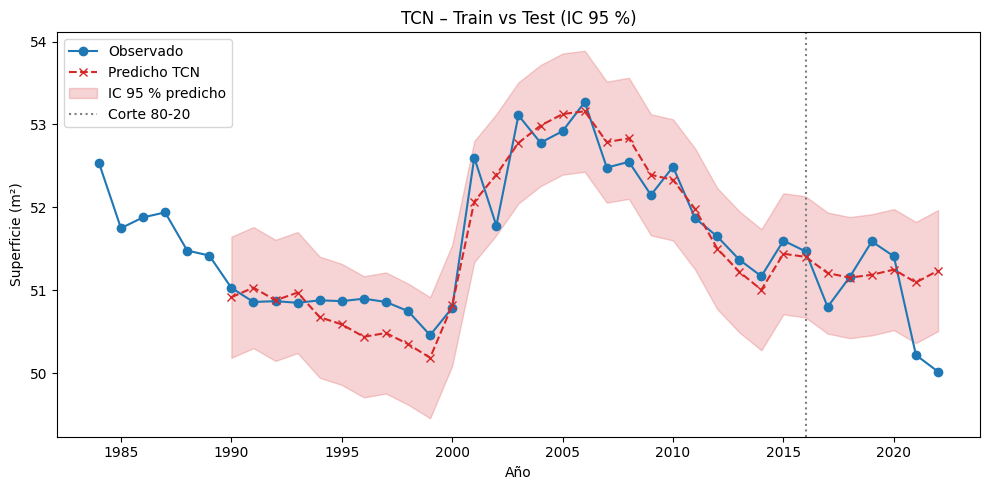

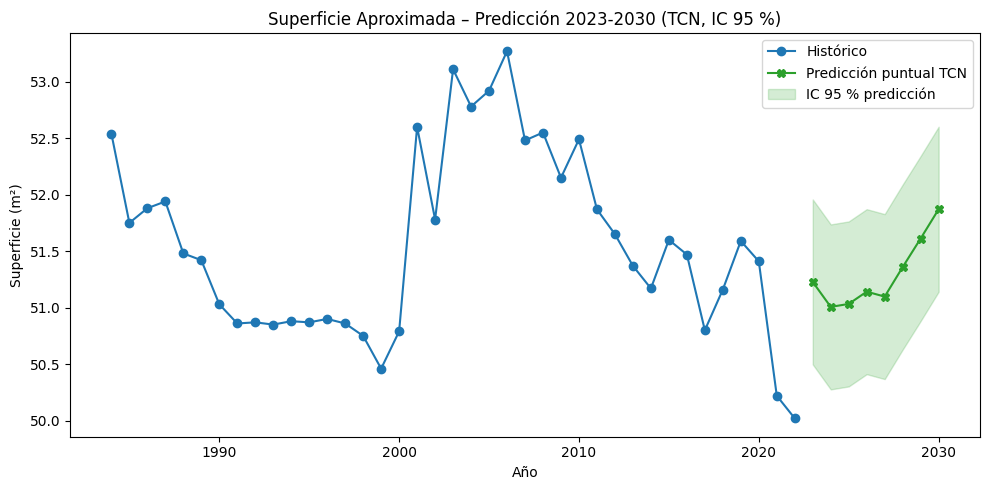

In [18]:

# Reproducibilidad total
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
tf.config.experimental.enable_op_determinism()

# =====================================================================
# 2. Pre‑procesamiento
# =====================================================================
# Usamos datos con etiqueta (hasta 2022 incluido)
df = df_sin_dique.copy()
df["Año"] = df["Año"].astype(int)
df_hist = df[df["Año"] <= 2022].copy()

# Relleno básico de NA en superficie
mean_surface = df_hist["Superficie_Aproximada"].mean()
df_hist["Superficie_Aproximada"].fillna(mean_surface, inplace=True)

FEATURES = [
    "Precipitaciones_Anuales",
    "Temperatura_Minima_Media",
    "Temperatura_Maxima_Media",
    "Presencia_Dique",
]
TARGET = "Superficie_Aproximada"

# Escalado Min‑Max independiente
x_scaler, y_scaler = StandardScaler(), StandardScaler()
X_scaled = x_scaler.fit_transform(df_hist[FEATURES])
y_scaled = y_scaler.fit_transform(df_hist[[TARGET]])

# -------------------------------------------------------------
# Crear secuencias ventana deslizante
# -------------------------------------------------------------
WINDOW_SIZE = 6

def create_sequences(X, y, window):
    xs, ys = [], []
    for i in range(len(X) - window):
        xs.append(X[i : i + window])
        ys.append(y[i + window])
    return np.asarray(xs), np.asarray(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, WINDOW_SIZE)

# ---------------------------------------------------------------------
# 2. Aplanar las ventanas
# ---------------------------------------------------------------------
X_seq_flat = X_seq.reshape(X_seq.shape[0], -1)   # (n_seq, window * n_features)
y_seq_flat = y_seq.flatten()
split_idx = int(len(X_seq) * SPLIT_RATIO)
X_train, y_train = X_seq[:split_idx], y_seq[:split_idx]
X_test,  y_test  = X_seq[split_idx:], y_seq[split_idx:]

print(f"Secuencias totales: {len(X_seq)}  |  Train: {len(X_train)}  |  Test: {len(X_test)}")

# =====================================================================
# 3. Modelo Temporal Convolutional Network (TCN)
# =====================================================================

def tcn_residual_block(x, filters, kernel_size, dilation, seed):
    """Bloque residual TCN: Conv1D→Dropout→Conv1D→Add→ReLU"""
    prev = x
    x = layers.Conv1D(filters,
                      kernel_size,
                      padding="causal",
                      dilation_rate=dilation,
                      activation="relu",
                      kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed))(x)
    x = layers.Dropout(0.2, seed=seed)(x)
    x = layers.Conv1D(filters,
                      kernel_size,
                      padding="causal",
                      dilation_rate=dilation,
                      activation="relu",
                      kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed+1))(x)
    x = layers.Dropout(0.2, seed=seed)(x)

    # Ajuste de canales si hace falta
    if prev.shape[-1] != filters:
        prev = layers.Conv1D(filters, 1, padding="same",
                             kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed))(prev)
    x = layers.Add()([x, prev])
    return layers.Activation("relu")(x)

# ----- Arquitectura -----
inputs = layers.Input(shape=(WINDOW_SIZE, len(FEATURES)))

x = tcn_residual_block(inputs, 32, kernel_size=3, dilation=1, seed=SEED)
x = tcn_residual_block(x, 32, kernel_size=3, dilation=2, seed=SEED+10)
x = tcn_residual_block(x, 32, kernel_size=3, dilation=4, seed=SEED+20)
x = tcn_residual_block(x, 32, 3, dilation=8, seed=SEED+30)



x = layers.GlobalAveragePooling1D()(x)   # colapsa dimensión temporal
outputs = layers.Dense(1)(x)

model = models.Model(inputs, outputs, name="TCN")

model.compile(
    optimizer=tf.keras.optimizers.Adam(9e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae"]
)

model.summary()

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=250,
    batch_size=1,
    shuffle=False,
    callbacks=[callbacks.EarlyStopping(
        monitor="val_loss", patience=10, min_delta=5e-4,
        restore_best_weights=True)],
    verbose=2
)

# =====================================================================
# 4. Métricas en test e intervalo de confianza
# =====================================================================
y_pred_test     = model.predict(X_test).flatten()
y_pred_test_inv = y_scaler.inverse_transform(y_pred_test.reshape(-1, 1)).flatten()
y_test_inv      = y_scaler.inverse_transform(y_test).flatten()

mae_val  = mean_absolute_error(y_test_inv, y_pred_test_inv)
rmse_val = mean_squared_error(y_test_inv, y_pred_test_inv)

print("\n≫ Métricas en test (20 %)")
print(f"MAE : {mae_val:.3f}")
print(f"RMSE: {rmse_val:.3f}")

Z = 1.96   # factor IC 95 %

# =====================================================================
# 5. Predicción 2023-2030
# =====================================================================
df_future = df[df["Año"] >= START_PRED - WINDOW_SIZE].copy().reset_index(drop=True)
df_future[TARGET].fillna(mean_surface, inplace=True)

X_future_scaled  = x_scaler.transform(df_future[FEATURES])
X_future_seq, _  = create_sequences(X_future_scaled,
                                    np.zeros_like(X_future_scaled[:, :1]),
                                    WINDOW_SIZE)

preds_future_inv = y_scaler.inverse_transform(
    model.predict(X_future_seq)).flatten()
future_years = df_future["Año"].iloc[WINDOW_SIZE:].values

df_preds = pd.DataFrame({"Año": future_years,
                         "Superficie_Predicha": preds_future_inv})
df_preds.to_csv("predictions_2023_2030_tcn.csv", index=False)
print("Predicciones 2023-2030 → predictions_2023_2030_tcn.csv")

# =====================================================================
# 6. Gráficas con bandas de IC ±1.96·RMSE  (idéntico a tu bloque)
# =====================================================================
try:
    import matplotlib.pyplot as plt

    # --- 6.1 Train/Test ---
    years_hist     = df_hist["Año"].iloc[WINDOW_SIZE:]
    preds_hist_inv = y_scaler.inverse_transform(
        model.predict(X_seq).reshape(-1, 1)).flatten()
    ci_upper_hist  = preds_hist_inv + Z * rmse_val
    ci_lower_hist  = preds_hist_inv - Z * rmse_val
    split_year     = years_hist.iloc[split_idx]

    plt.figure(figsize=(10, 5))
    plt.plot(df_hist["Año"], df_hist[TARGET], label="Observado", marker="o")
    plt.plot(years_hist, preds_hist_inv, linestyle="--", marker="x",
             color="tab:red", label="Predicho TCN")
    plt.fill_between(years_hist, ci_lower_hist, ci_upper_hist,
                     color="tab:red", alpha=0.2, label="IC 95 % predicho")
    plt.axvline(x=split_year, color="gray", linestyle=":", label="Corte 80-20")
    plt.title("TCN – Train vs Test (IC 95 %)")
    plt.xlabel("Año"); plt.ylabel("Superficie (m²)"); plt.legend(); plt.tight_layout(); plt.show()

    # --- 6.2 Futuro ---
    ci_upper_future = preds_future_inv + Z * rmse_val
    ci_lower_future = preds_future_inv - Z * rmse_val

    plt.figure(figsize=(10, 5))
    plt.plot(df["Año"], df[TARGET], label="Histórico", marker="o")
    plt.plot(df_preds["Año"], df_preds["Superficie_Predicha"],
             label="Predicción puntual TCN", marker="X", color="tab:green")
    plt.fill_between(df_preds["Año"], ci_lower_future, ci_upper_future,
                     color="tab:green", alpha=0.2, label="IC 95 % predicción")
    plt.title("Superficie Aproximada – Predicción 2023-2030 (TCN, IC 95 %)")
    plt.xlabel("Año"); plt.ylabel("Superficie (m²)"); plt.legend(); plt.tight_layout(); plt.show()

except ImportError:
    print("matplotlib no instalado: gráficos omitidos.")


Modelo TCN (con reinstalación del dique)

Secuencias totales: 33  |  Train: 26  |  Test: 7


/tmp/ipython-input-19-2975896284.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_hist["Superficie_Aproximada"].fillna(mean_surface, inplace=True)


Model: "TCN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 6, 4)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 6, 32)     │        416 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 6, 32)     │          0 │ conv1d_9[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 6, 32)     │      3,104 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 6, 32)     │          0 │ conv1d_10[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 6, 32)     │        160 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 6, 32)     │          0 │ dropout_13[0][0], │
│                     │                   │            │ conv1d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 6, 32)     │          0 │ add_4[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 6, 32)     │      3,104 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 6, 32)     │          0 │ conv1d_12[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 6, 32)     │      3,104 │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 6, 32)     │          0 │ conv1d_13[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 6, 32)     │          0 │ dropout_15[0][0], │
│                     │                   │            │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 6, 32)     │          0 │ add_5[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 6, 32)     │      3,104 │ activation_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 6, 32)     │          0 │ conv1d_14[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 6, 32)     │      3,104 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 6, 32)     │          0 │ conv1d_15[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 6, 32)     │          0 │ dropout_17[0][0], │
│                     │                   │            │ activation_5[0][

 Total params: 22,337 (87.25 KB)

 Trainable params: 22,337 (87.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/250
26/26 - 9s - 354ms/step - loss: 0.5901 - mae: 0.9666 - val_loss: 0.4515 - val_mae: 0.7678
Epoch 2/250
26/26 - 0s - 13ms/step - loss: 0.4019 - mae: 0.7795 - val_loss: 0.5534 - val_mae: 0.8988
Epoch 3/250
26/26 - 1s - 19ms/step - loss: 0.3254 - mae: 0.6981 - val_loss: 0.5309 - val_mae: 0.8577
Epoch 4/250
26/26 - 0s - 6ms/step - loss: 0.2721 - mae: 0.6031 - val_loss: 0.4916 - val_mae: 0.8007
Epoch 5/250
26/26 - 0s - 12ms/step - loss: 0.2166 - mae: 0.5549 - val_loss: 0.4830 - val_mae: 0.7949
Epoch 6/250
26/26 - 0s - 7ms/step - loss: 0.1973 - mae: 0.5409 - val_loss: 0.4528 - val_mae: 0.7644
Epoch 7/250
26/26 - 0s - 8ms/step - loss: 0.1871 - mae: 0.5232 - val_loss: 0.4446 - val_mae: 0.7534
Epoch 8/250
26/26 - 0s - 10ms/step - loss: 0.1875 - mae: 0.5094 - val_loss: 0.4118 - val_mae: 0.7207
Epoch 9/250
26/26 - 0s - 12ms/step - loss: 0.1618 - mae: 0.4630 - val_loss: 0.4573 - val_mae: 0.7664
Epoch 10/250
26/26 - 0s - 7ms/step - loss: 0.1557 - mae: 0.4489 - val_loss: 0.4499 - val_mae:

/tmp/ipython-input-19-2975896284.py:143: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_future[TARGET].fillna(mean_surface, inplace=True)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
Predicciones 2023-2030 → predictions_2023_2030_tcn.csv
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


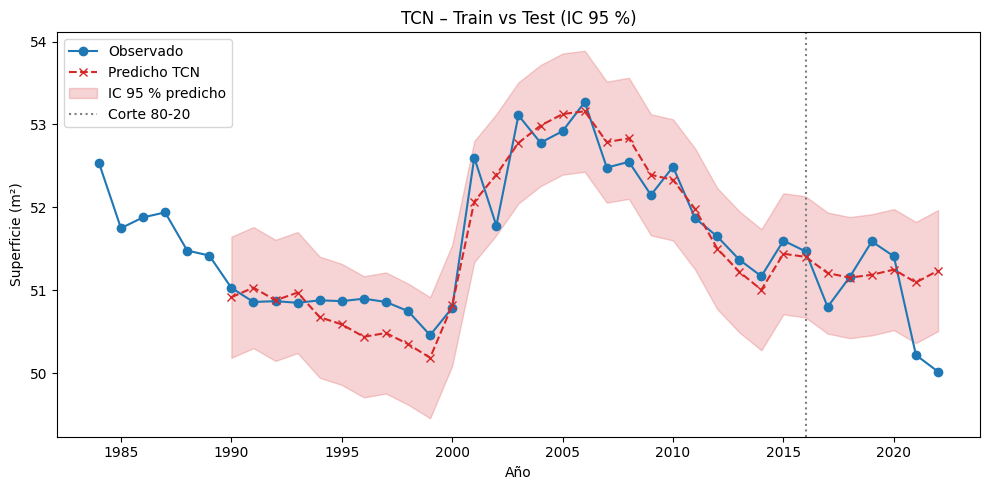

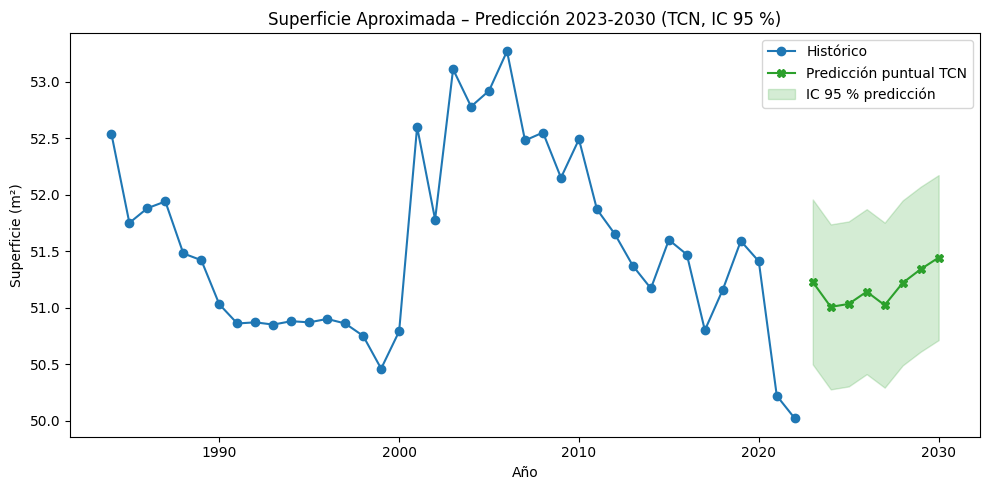

In [19]:

# Reproducibilidad total
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
tf.config.experimental.enable_op_determinism()

# =====================================================================
# 2. Pre‑procesamiento
# =====================================================================
# Usamos datos con etiqueta (hasta 2022 incluido)
df = df_con_dique.copy()
df["Año"] = df["Año"].astype(int)
df_hist = df[df["Año"] <= 2022].copy()

# Relleno básico de NA en superficie
mean_surface = df_hist["Superficie_Aproximada"].mean()
df_hist["Superficie_Aproximada"].fillna(mean_surface, inplace=True)

FEATURES = [
    "Precipitaciones_Anuales",
    "Temperatura_Minima_Media",
    "Temperatura_Maxima_Media",
    "Presencia_Dique",
]
TARGET = "Superficie_Aproximada"

# Escalado Min‑Max independiente
x_scaler, y_scaler = StandardScaler(), StandardScaler()
X_scaled = x_scaler.fit_transform(df_hist[FEATURES])
y_scaled = y_scaler.fit_transform(df_hist[[TARGET]])

# -------------------------------------------------------------
# Crear secuencias ventana deslizante
# -------------------------------------------------------------
WINDOW_SIZE = 6

def create_sequences(X, y, window):
    xs, ys = [], []
    for i in range(len(X) - window):
        xs.append(X[i : i + window])
        ys.append(y[i + window])
    return np.asarray(xs), np.asarray(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, WINDOW_SIZE)

# ---------------------------------------------------------------------
# 2. Aplanar las ventanas
# ---------------------------------------------------------------------
X_seq_flat = X_seq.reshape(X_seq.shape[0], -1)   # (n_seq, window * n_features)
y_seq_flat = y_seq.flatten()
split_idx = int(len(X_seq) * SPLIT_RATIO)
X_train, y_train = X_seq[:split_idx], y_seq[:split_idx]
X_test,  y_test  = X_seq[split_idx:], y_seq[split_idx:]

print(f"Secuencias totales: {len(X_seq)}  |  Train: {len(X_train)}  |  Test: {len(X_test)}")

# =====================================================================
# 3. Modelo Temporal Convolutional Network (TCN)
# =====================================================================

def tcn_residual_block(x, filters, kernel_size, dilation, seed):
    """Bloque residual TCN: Conv1D→Dropout→Conv1D→Add→ReLU"""
    prev = x
    x = layers.Conv1D(filters,
                      kernel_size,
                      padding="causal",
                      dilation_rate=dilation,
                      activation="relu",
                      kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed))(x)
    x = layers.Dropout(0.2, seed=seed)(x)
    x = layers.Conv1D(filters,
                      kernel_size,
                      padding="causal",
                      dilation_rate=dilation,
                      activation="relu",
                      kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed+1))(x)
    x = layers.Dropout(0.2, seed=seed)(x)

    # Ajuste de canales si hace falta
    if prev.shape[-1] != filters:
        prev = layers.Conv1D(filters, 1, padding="same",
                             kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed))(prev)
    x = layers.Add()([x, prev])
    return layers.Activation("relu")(x)

# ----- Arquitectura -----
inputs = layers.Input(shape=(WINDOW_SIZE, len(FEATURES)))

x = tcn_residual_block(inputs, 32, kernel_size=3, dilation=1, seed=SEED)
x = tcn_residual_block(x, 32, kernel_size=3, dilation=2, seed=SEED+10)
x = tcn_residual_block(x, 32, kernel_size=3, dilation=4, seed=SEED+20)
x = tcn_residual_block(x, 32, 3, dilation=8, seed=SEED+30)



x = layers.GlobalAveragePooling1D()(x)   # colapsa dimensión temporal
outputs = layers.Dense(1)(x)

model = models.Model(inputs, outputs, name="TCN")

model.compile(
    optimizer=tf.keras.optimizers.Adam(9e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae"]
)

model.summary()

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=250,
    batch_size=1,
    shuffle=False,
    callbacks=[callbacks.EarlyStopping(
        monitor="val_loss", patience=10, min_delta=5e-4,
        restore_best_weights=True)],
    verbose=2
)

# =====================================================================
# 4. Métricas en test e intervalo de confianza
# =====================================================================
y_pred_test     = model.predict(X_test).flatten()
y_pred_test_inv = y_scaler.inverse_transform(y_pred_test.reshape(-1, 1)).flatten()
y_test_inv      = y_scaler.inverse_transform(y_test).flatten()

mae_val  = mean_absolute_error(y_test_inv, y_pred_test_inv)
rmse_val = mean_squared_error(y_test_inv, y_pred_test_inv)

print("\n≫ Métricas en test (20 %)")
print(f"MAE : {mae_val:.3f}")
print(f"RMSE: {rmse_val:.3f}")

Z = 1.96   # factor IC 95 %

# =====================================================================
# 5. Predicción 2023-2030
# =====================================================================
df_future = df[df["Año"] >= START_PRED - WINDOW_SIZE].copy().reset_index(drop=True)
df_future[TARGET].fillna(mean_surface, inplace=True)

X_future_scaled  = x_scaler.transform(df_future[FEATURES])
X_future_seq, _  = create_sequences(X_future_scaled,
                                    np.zeros_like(X_future_scaled[:, :1]),
                                    WINDOW_SIZE)

preds_future_inv = y_scaler.inverse_transform(
    model.predict(X_future_seq)).flatten()
future_years = df_future["Año"].iloc[WINDOW_SIZE:].values

df_preds = pd.DataFrame({"Año": future_years,
                         "Superficie_Predicha": preds_future_inv})
df_preds.to_csv("predictions_2023_2030_tcn.csv", index=False)
print("Predicciones 2023-2030 → predictions_2023_2030_tcn.csv")

# =====================================================================
# 6. Gráficas con bandas de IC ±1.96·RMSE  (idéntico a tu bloque)
# =====================================================================
try:
    import matplotlib.pyplot as plt

    # --- 6.1 Train/Test ---
    years_hist     = df_hist["Año"].iloc[WINDOW_SIZE:]
    preds_hist_inv = y_scaler.inverse_transform(
        model.predict(X_seq).reshape(-1, 1)).flatten()
    ci_upper_hist  = preds_hist_inv + Z * rmse_val
    ci_lower_hist  = preds_hist_inv - Z * rmse_val
    split_year     = years_hist.iloc[split_idx]

    plt.figure(figsize=(10, 5))
    plt.plot(df_hist["Año"], df_hist[TARGET], label="Observado", marker="o")
    plt.plot(years_hist, preds_hist_inv, linestyle="--", marker="x",
             color="tab:red", label="Predicho TCN")
    plt.fill_between(years_hist, ci_lower_hist, ci_upper_hist,
                     color="tab:red", alpha=0.2, label="IC 95 % predicho")
    plt.axvline(x=split_year, color="gray", linestyle=":", label="Corte 80-20")
    plt.title("TCN – Train vs Test (IC 95 %)")
    plt.xlabel("Año"); plt.ylabel("Superficie (m²)"); plt.legend(); plt.tight_layout(); plt.show()

    # --- 6.2 Futuro ---
    ci_upper_future = preds_future_inv + Z * rmse_val
    ci_lower_future = preds_future_inv - Z * rmse_val

    plt.figure(figsize=(10, 5))
    plt.plot(df["Año"], df[TARGET], label="Histórico", marker="o")
    plt.plot(df_preds["Año"], df_preds["Superficie_Predicha"],
             label="Predicción puntual TCN", marker="X", color="tab:green")
    plt.fill_between(df_preds["Año"], ci_lower_future, ci_upper_future,
                     color="tab:green", alpha=0.2, label="IC 95 % predicción")
    plt.title("Superficie Aproximada – Predicción 2023-2030 (TCN, IC 95 %)")
    plt.xlabel("Año"); plt.ylabel("Superficie (m²)"); plt.legend(); plt.tight_layout(); plt.show()

except ImportError:
    print("matplotlib no instalado: gráficos omitidos.")


Los resultados confirman la superioridad de los modelos basados en redes neuronales para capturar la variabilidad interanual de la superficie del lago Caburgua. La flexibilidad no lineal de LSTM y TCN resulta particularmente ventajosa al incorporar predicciones de covariables climáticas generadas también con redes neuronales.

Respecto al desempeño numérico mediante las métricas de error absoluto medio (MAE) y raíz del error cuadrático medio (RMSE), se observaron pequeñas diferencias según el lago estudiado. Para Caburgua, TCN mostró ligeramente mejor desempeño en términos de MAE (0.448 km2), mientras que LSTM presentó resultados más robustos en términos de RMSE (0.336 km2)

Un hallazgo relevante es la evidencia estadística del efecto negativo del dique en el río Trafampulli sobre la superficie del lago Caburgua, consistente con las conclusiones previas del informe Sustenta Pucón (14). La proyección al año 2030 indicó que, sin la reinstalación del dique, la superficie alcanzaría cerca de 52 km2, mientras que con una hipotética reinstalación para 2026, se reduciría a aproximadamente 51 km2. Esto confirma la importancia de considerar explícitamente variables antrópicas al planificar acciones de manejo hídrico.
